# Decision Tree Classification Assignment

**Dataset:** `heart_disease.xlsx`  

This notebook covers:

1. Data loading
2. Exploratory Data Analysis (EDA)
3. Missing value and outlier checking
4. Feature engineering
5. Decision Tree Classification
6. Model evaluation
7. Hyperparameter tuning
8. Decision tree visualization
9. Feature importance
10. Interview questions

## 1. Import Required Libraries

In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load the Dataset

The dataset is loaded using `pandas.read_excel()` because the file is in `.xlsx` format.

In [2]:
# Load dataset
file_path = "heart_disease.xlsx"
df = pd.read_excel(file_path)

# Display first five rows
df.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


In [3]:
# Dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 12
Number of columns: 2


In [4]:
# Basic information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           12 non-null     object
 1   Age in years  12 non-null     object
dtypes: object(2)
memory usage: 320.0+ bytes


In [5]:
# Display column names
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['age', 'Age in years']


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset structure, feature types, missing values, outliers, and relationships between variables.

In [6]:
# Summary statistics for numerical columns
df.describe().T

,count,unique,top,freq
age,12,12,Gender,1
Age in years,12,12,"Gender ; Male - 1, Female -0",1


In [7]:
# Check missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [8]:
# If there are missing values, handle them
# Numerical columns -> fill with median
# Categorical columns -> fill with mode

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after treatment:")
print(df.isnull().sum().sum())

Missing values after treatment:
0


In [9]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if present
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (12, 2)


## 4. Identify Target Column

For heart disease datasets, the target column is usually named `target`, `HeartDisease`, `output`, `num`, or similar.

The code below automatically detects a likely target column. If it selects the wrong column, manually replace `target_col` with the correct column name.

In [10]:
# Automatically detect target column
possible_targets = ['target', 'Target', 'heart_disease', 'HeartDisease', 'Heart Disease', 'output', 'Output', 'num', 'class', 'Class']

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

# If no common target name is found, assume the last column is target
if target_col is None:
    target_col = df.columns[-1]

print("Selected target column:", target_col)
print(df[target_col].value_counts())

Selected target column: Age in years
Age in years
Gender ; Male - 1, Female -0                                                                                                                                                                                                                                                         1
Chest pain type                                                                                                                                                                                                                                                                      1
Resting blood pressure                                                                                                                                                                                                                                                               1
cholesterol measure                                                                                              

## 5. Data Visualization

In [12]:
# Histograms for numerical features
num_cols = df.select_dtypes(include=np.number).columns.tolist()

if num_cols:
    plt.figure(figsize=(15, 12))
    df[num_cols].hist(figsize=(15, 12), bins=20)
    plt.suptitle("Histograms of Numerical Features")
    plt.show()
else:
    print("No numerical columns available for histogram plotting.")

No numerical columns available for histogram plotting.


In [13]:
# Boxplots for numerical features to identify outliers
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

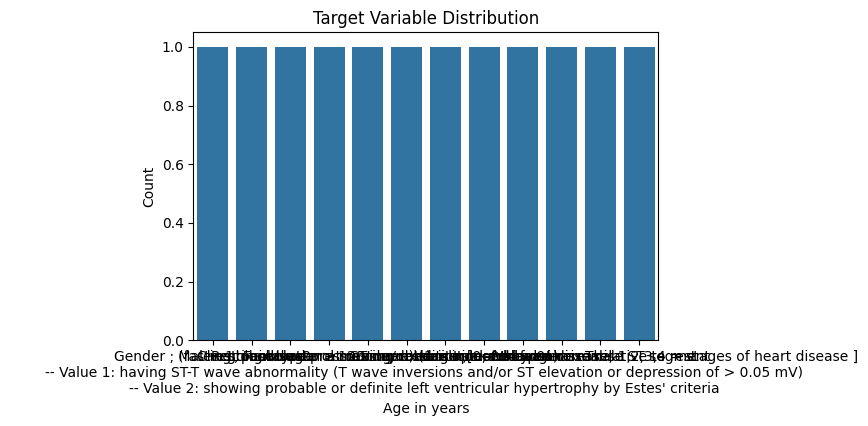

In [15]:
# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_col])
plt.title("Target Variable Distribution")
plt.xlabel(target_col)
plt.ylabel("Count")
plt.show()

## 6. Outlier Treatment using IQR Capping

Decision Trees are less sensitive to outliers compared to linear models, but checking outliers is still useful during EDA. Here, we use IQR capping to reduce extreme values.

In [16]:
# IQR capping for numerical columns except target
num_features = [col for col in num_cols if col != target_col]

df_capped = df.copy()

for col in num_features:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])

print("Outlier capping completed")

Outlier capping completed


## 7. Feature Engineering

Categorical variables must be converted into numerical form before training the model.

- Label Encoding is used for binary categories.
- One-Hot Encoding is used for multi-class categorical variables.

Decision Trees do not require feature scaling, so scaling is not mandatory here.

In [17]:
# Separate features and target
X = df_capped.drop(columns=[target_col])
y = df_capped[target_col]

# Encode target if it is categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature matrix shape: (12, 11)
Target shape: (12,)


,age_chol,age_cp,age_exang,age_fbs,age_num,age_oldpeak,age_restecg,age_slope,age_thal,age_thalch,age_trestbps
0,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True
3,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False


## 8. Train-Test Split

The dataset is split into 80% training data and 20% testing data.

In [24]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Convert y to pandas Series if it is numpy array
y_series = pd.Series(y)

# Check class distribution
print(y_series.value_counts())

# If any class has less than 2 samples, do not use stratify
if y_series.value_counts().min() < 2:
    print("Some classes have only 1 sample, so stratify is removed.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42
    )
else:
    print("Stratified split applied.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

2     1
1     1
3     1
6     1
0     1
7     1
9     1
8     1
4     1
11    1
5     1
10    1
Name: count, dtype: int64
Some classes have only 1 sample, so stratify is removed.
Training data shape: (9, 11)
Testing data shape: (3, 11)
Training target shape: (9,)
Testing target shape: (3,)


## 9. Build Decision Tree Classifier

In [25]:
# Create Decision Tree model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] if len(np.unique(y)) == 2 else None

print("Decision Tree model trained successfully")

Decision Tree model trained successfully


## 10. Model Evaluation

In [26]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

# ROC-AUC only for binary classification
if y_pred_proba is not None:
    auc = roc_auc_score(y_test, y_pred_proba)
    print("ROC-AUC Score:", round(auc, 4))

Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


In [27]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00       1.0
          11       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# ROC Curve for binary classification
if y_pred_proba is not None:
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title("ROC Curve - Decision Tree")
    plt.show()
else:
    print("ROC curve is shown only for binary classification.")

## 11. Hyperparameter Tuning using GridSearchCV

We tune important Decision Tree hyperparameters:

- `criterion`: Function used to measure split quality.
- `max_depth`: Maximum depth of the tree.
- `min_samples_split`: Minimum samples required to split an internal node.
- `min_samples_leaf`: Minimum samples required at a leaf node.

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", round(grid_search.best_score_, 4))

In [ ]:
# Evaluate tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_pred_tuned_proba = best_model.predict_proba(X_test)[:, 1] if len(np.unique(y)) == 2 else None

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted')
recall_tuned = recall_score(y_test, y_pred_tuned, average='weighted')
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted')

print("Tuned Model Accuracy:", round(accuracy_tuned, 4))
print("Tuned Model Precision:", round(precision_tuned, 4))
print("Tuned Model Recall:", round(recall_tuned, 4))
print("Tuned Model F1 Score:", round(f1_tuned, 4))

if y_pred_tuned_proba is not None:
    auc_tuned = roc_auc_score(y_test, y_pred_tuned_proba)
    print("Tuned Model ROC-AUC Score:", round(auc_tuned, 4))

In [ ]:
# Compare base and tuned model
comparison = pd.DataFrame({
    'Model': ['Base Decision Tree', 'Tuned Decision Tree'],
    'Accuracy': [accuracy, accuracy_tuned],
    'Precision': [precision, precision_tuned],
    'Recall': [recall, recall_tuned],
    'F1 Score': [f1, f1_tuned]
})

comparison

## 12. Visualize Decision Tree

The decision tree visualization helps us understand the rules learned by the model.

In [ ]:
plt.figure(figsize=(22, 12))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[str(cls) for cls in np.unique(y)],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Visualization - Top Levels")
plt.show()

## 13. Feature Importance

Feature importance shows which variables contributed most to the model's predictions.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title("Top 10 Important Features")
plt.show()

## 14. Final Interpretation

Write your observations based on the model outputs:

- The Decision Tree classifier was trained to predict heart disease using patient-related features.
- EDA helped identify missing values, outliers, feature distributions, and correlations.
- Categorical variables were converted into numerical format using one-hot encoding.
- The base Decision Tree model was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.
- Hyperparameter tuning helped control overfitting and improved model generalization.
- Feature importance helped identify the most influential variables for prediction.

**Conclusion:**  
Decision Tree is an easy-to-interpret supervised machine learning algorithm. It is useful for classification problems because it creates rule-based decisions. However, it can overfit if the tree becomes too deep. Therefore, hyperparameter tuning is important for better performance.

# Interview Questions

## 1. What are some common hyperparameters of Decision Tree models, and how do they affect model performance?

Common Decision Tree hyperparameters are:

1. **criterion**  
   It decides how the quality of a split is measured. Common values are `gini` and `entropy`.  
   - `gini` measures impurity.
   - `entropy` uses information gain.

2. **max_depth**  
   It controls the maximum depth of the tree.  
   - Higher depth can make the model complex and may cause overfitting.
   - Lower depth makes the model simpler and may cause underfitting.

3. **min_samples_split**  
   It is the minimum number of samples required to split an internal node.  
   - Higher value reduces overfitting.
   - Lower value allows more splits and creates a deeper tree.

4. **min_samples_leaf**  
   It is the minimum number of samples required in a leaf node.  
   - Higher value makes the tree more generalized.
   - Lower value may make the model memorize training data.

5. **max_features**  
   It controls how many features are considered while finding the best split.  
   It can help reduce overfitting.

6. **splitter**  
   It decides the strategy used to split each node. Common values are `best` and `random`.

In simple words, hyperparameters control the size, complexity, and learning behavior of the Decision Tree. Proper tuning helps improve accuracy and reduce overfitting.

## 2. What is the difference between Label Encoding and One-Hot Encoding?

**Label Encoding:**  
Label Encoding converts categories into integer values.

Example:

| Category | Encoded Value |
|---|---|
| Male | 0 |
| Female | 1 |

It is useful when the categorical variable has an order, such as low, medium, and high.

**One-Hot Encoding:**  
One-Hot Encoding creates separate binary columns for each category.

Example:

| Color | Color_Red | Color_Blue | Color_Green |
|---|---:|---:|---:|
| Red | 1 | 0 | 0 |
| Blue | 0 | 1 | 0 |

It is useful when categories do not have any natural order, such as city names, color names, or gender.

**Main Difference:**  
Label Encoding gives numeric labels to categories, while One-Hot Encoding creates separate columns with 0 and 1 values. One-Hot Encoding avoids giving false order to categories.